[15:34:35] DEPRECATION WARNING: please use MorganGenerator
[15:34:36] DEPRECATION WARNING: please use MorganGenerator
[15:34:36] DEPRECATION WARNING: please use MorganGenerator
[15:34:36] DEPRECATION WARNING: please use MorganGenerator
[15:34:36] DEPRECATION WARNING: please use MorganGenerator
[15:34:36] DEPRECATION WARNING: please use MorganGenerator
[15:34:36] DEPRECATION WARNING: please use MorganGenerator
[15:34:36] DEPRECATION WARNING: please use MorganGenerator
[15:34:36] DEPRECATION WARNING: please use MorganGenerator
[15:34:36] DEPRECATION WARNING: please use MorganGenerator
[15:34:36] DEPRECATION WARNING: please use MorganGenerator
[15:34:36] DEPRECATION WARNING: please use MorganGenerator
[15:34:36] DEPRECATION WARNING: please use MorganGenerator
[15:34:36] DEPRECATION WARNING: please use MorganGenerator
[15:34:36] DEPRECATION WARNING: please use MorganGenerator
[15:34:36] DEPRECATION WARNING: please use MorganGenerator
[15:34:36] DEPRECATION WARNING: please use MorganGenerat


=== Training RandomForest ===


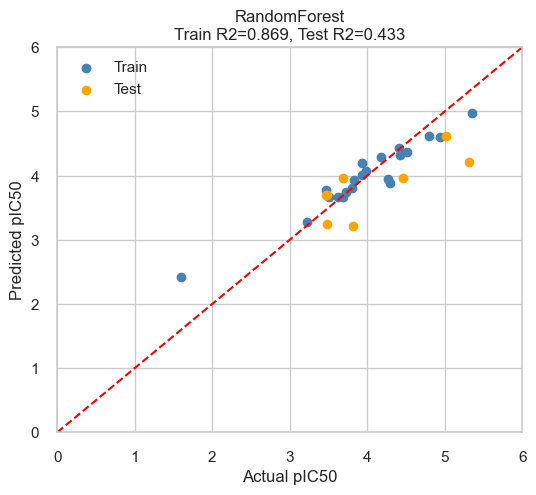

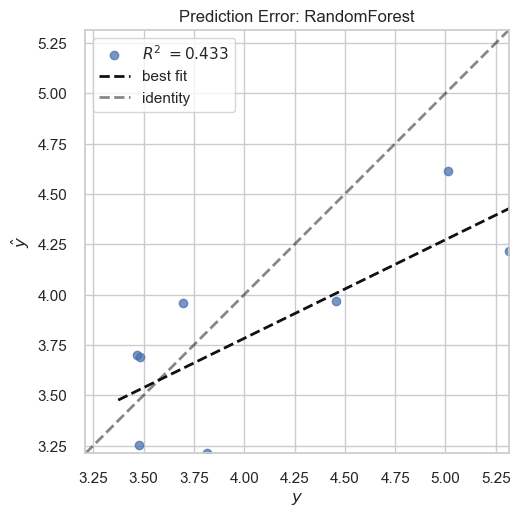

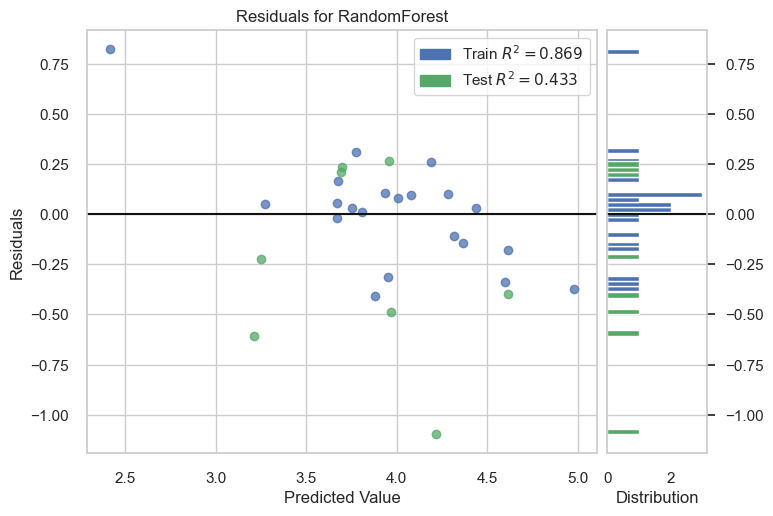


=== Training KNN ===


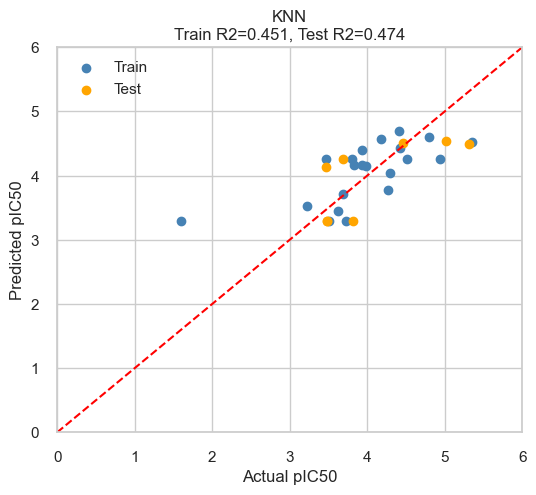

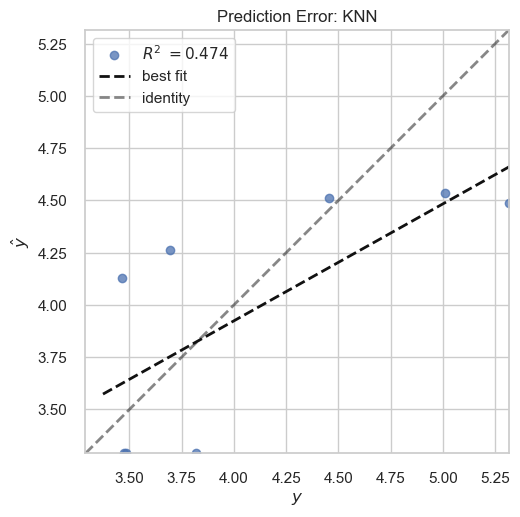

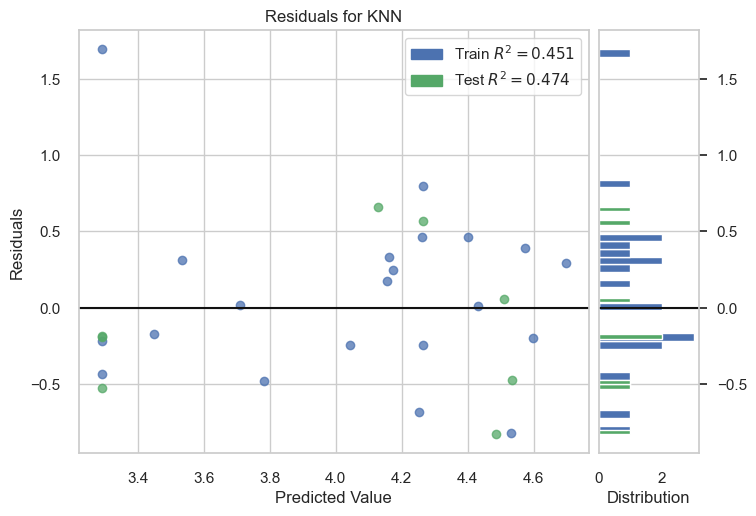


=== Training SVR ===


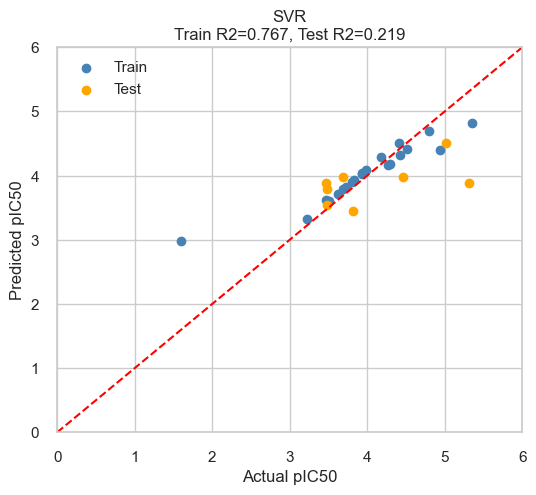

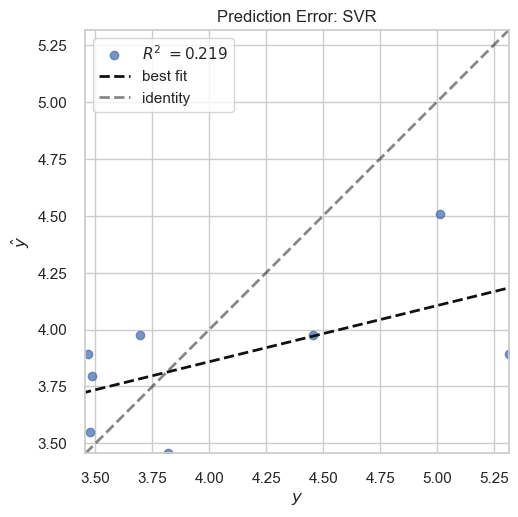

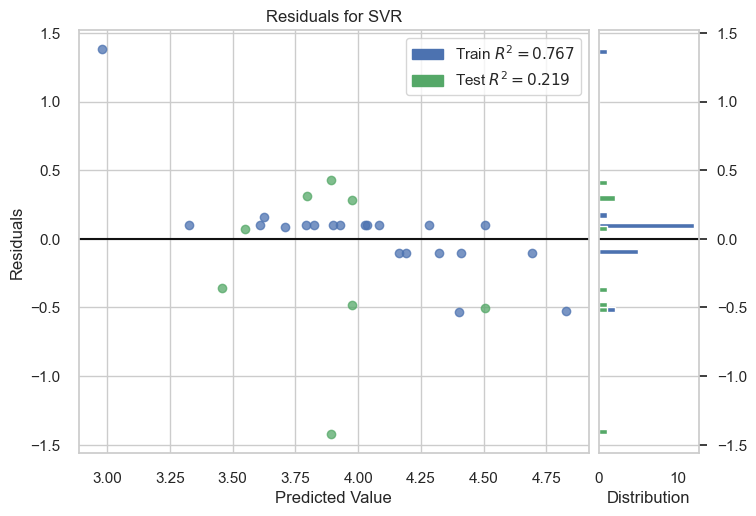


=== Y-RANDOMISED RESULTS (50 permutations) ===
RandomForest: mean R2=-0.175 ± 0.379
KNN: mean R2=-0.159 ± 0.429
SVR: mean R2=-0.105 ± 0.192

=== COMBINED TABLE: REAL vs. RANDOM R2 ===


,R2,RandR2_mean,RandR2_std
RandomForest,0.432804,-0.174809,0.378564
KNN,0.473741,-0.158652,0.428899
SVR,0.218854,-0.105438,0.192042



Done! You have a pIC50 regression pipeline with RandomForest, KNN, SVR.
For each model, real R2 is stored in df_results, random R2 distribution in random_r2.
final_table merges them, so you can do significance tests in a separate cell.


In [1]:
###############################################################################
# SINGLE CELL: pIC50 REGRESSION WORKFLOW WITH RandomForest, KNN, SVR
#  - Axis range 0..6 for train/test scatter
#  - Yellowbrick visuals: PredictionError & ResidualsPlot for each model
#  - ADDED: Y-randomization for R², final table with real vs. random R²
#  - Return random_r2 for significance test in a separate cell
###############################################################################

import os
import zipfile
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# RDKit
from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem
from rdkit.Chem.Descriptors import _descList

# scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_squared_error, r2_score, mean_absolute_error
)

# Regressors
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

# Yellowbrick for regression visuals
from yellowbrick.regressor import PredictionError, ResidualsPlot

sns.set(style='whitegrid')

###############################################################################
# 1. Load & Parse Data, Convert IC50 -> pIC50
###############################################################################
zip_path = r"M:\CHEM380\CHEM380\Project Data\SVMP_IC50_data.zip"
extract_dir = "./extracted_svmp"
os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_dir)

df_path = os.path.join(extract_dir, "CR.csv")
df = pd.read_csv(df_path)
df.columns = [c.strip() for c in df.columns]

# Suppose your numeric column is "CR_IC50" in µM. We rename it to "IC50":
if "CR_IC50" in df.columns:
    df.rename(columns={"CR_IC50": "IC50"}, inplace=True)
else:
    # fallback if you prefer the second column
    df.rename(columns={df.columns[1]: "IC50"}, inplace=True)

if "Smiles" in df.columns:
    df.rename(columns={"Smiles": "SMILES"}, inplace=True)

df = df[['SMILES','IC50']].dropna()

def parse_ic50_value(x):
    """
    Skip data points with '>' or '<' by returning NaN.
    Remove 'uM','µM', then parse as float.
    """
    s = str(x).strip()
    if ('<' in s) or ('>' in s):
        return np.nan
    s = s.replace("µM","").replace("uM","").strip()
    try:
        val = float(s)
        return val
    except ValueError:
        return np.nan

df['IC50'] = df['IC50'].apply(parse_ic50_value)
df.dropna(subset=['IC50'], inplace=True)

# Convert IC50(µM)-> pIC50 = -log10(IC50 in M)
df['pIC50'] = -np.log10(df['IC50'] * 1e-6)

###############################################################################
# 2. Compute RDKit Descriptors (including MorganFpDensity)
###############################################################################
def compute_all_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    desc_vals = {}
    for (desc_name, desc_func) in _descList:
        desc_vals[desc_name] = desc_func(mol)
    # Morgan fingerprint density
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, 2, 1024)
    arr = np.zeros((1024,), dtype=int)
    DataStructs.ConvertToNumpyArray(fp, arr)
    desc_vals["MorganFpDensity"] = np.sum(arr)/1024
    return desc_vals

desc_list = []
for _, row in df.iterrows():
    dvals = compute_all_descriptors(row['SMILES'])
    desc_list.append(dvals)

df_desc = pd.DataFrame(desc_list)
df_desc['pIC50'] = df['pIC50'].values
df_desc.dropna(inplace=True)

###############################################################################
# 3. Remove correlated features function
###############################################################################
def remove_corr_features(X, corr_thresh=0.9):
    import pandas as pd
    df_temp = pd.DataFrame(X)
    corr_matrix = df_temp.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [col for col in upper.columns if any(upper[col] > corr_thresh)]
    keep_cols = np.setdiff1d(np.arange(X.shape[1]), to_drop)
    return keep_cols

###############################################################################
# 4. Train/Test split, scale, correlation removal
###############################################################################
X_all = df_desc.drop(columns=["pIC50"], errors="ignore").values
y_all = df_desc["pIC50"].values

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.25, random_state=42
)

# skip advanced oversampling for numeric by default
X_train_bal, y_train_bal = X_train, y_train

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled  = scaler.transform(X_test)

keep_cols = remove_corr_features(X_train_scaled, corr_thresh=0.9)
X_train_final = X_train_scaled[:, keep_cols]
X_test_final  = X_test_scaled[:, keep_cols]

original_feature_names = [c for c in df_desc.columns if c != "pIC50"]
feature_names = [original_feature_names[i] for i in keep_cols]

###############################################################################
# 5. Define Regressors (RandomForest, KNN, SVR)
###############################################################################
models = {
    "RandomForest": RandomForestRegressor(random_state=42),
    "KNN": KNeighborsRegressor(),
    "SVR": SVR()
}

###############################################################################
# 6. For each model, train, produce scatter plot (0..6), Yellowbrick plots
###############################################################################
from yellowbrick.regressor import PredictionError, ResidualsPlot

def scatter_train_test(model_name, y_train_true, y_train_pred, y_test_true, y_test_pred):
    """
    Produce a scatter plot of train vs. test predictions on the same figure,
    with axis range 0..6.
    """
    plt.figure(figsize=(6,5))
    plt.scatter(y_train_true, y_train_pred, color='steelblue', label='Train')
    plt.scatter(y_test_true,  y_test_pred,  color='orange',    label='Test')
    plt.plot([0,6],[0,6], color='red', ls='--')
    plt.xlim(0,6)
    plt.ylim(0,6)
    train_r2 = r2_score(y_train_true, y_train_pred)
    test_r2  = r2_score(y_test_true,  y_test_pred)
    plt.xlabel("Actual pIC50")
    plt.ylabel("Predicted pIC50")
    plt.title(f"{model_name}\nTrain R2={train_r2:.3f}, Test R2={test_r2:.3f}")
    plt.legend()
    plt.show()

# For storing final results
results = {}
trained_models = {}

# Train real models, produce visuals
for model_name, reg in models.items():
    print(f"\n=== Training {model_name} ===")
    reg.fit(X_train_final, y_train_bal)

    y_pred_train = reg.predict(X_train_final)
    y_pred_test  = reg.predict(X_test_final)

    # 6a) Scatter Plot with axis 0..6
    scatter_train_test(
        model_name,
        y_train_bal, y_pred_train,
        y_test,      y_pred_test
    )

    # 6b) Yellowbrick Prediction Error
    viz_pe = PredictionError(
        reg,
        identity=True,
        title=f"Prediction Error: {model_name}"
    )
    viz_pe.fit(X_train_final, y_train_bal)
    viz_pe.score(X_test_final, y_test)
    viz_pe.show()

    # 6c) Yellowbrick ResidualsPlot
    viz_resid = ResidualsPlot(
        reg,
        title=f"Residuals for {model_name}"
    )
    viz_resid.fit(X_train_final, y_train_bal)
    viz_resid.score(X_test_final, y_test)
    viz_resid.show()

    # Store real R2 in results
    real_r2 = r2_score(y_test, y_pred_test)
    results[model_name] = {"R2": real_r2}

# Convert to DataFrame
df_results = pd.DataFrame(results).T

###############################################################################
# 7. Y-Randomisation for R2
###############################################################################
num_random = 50
random_r2 = {m: [] for m in models.keys()}

for i in range(num_random):
    y_shuffled = np.random.permutation(y_train_bal)

    for model_name, reg in models.items():
        # create fresh instance of the same regressor type
        if model_name == "RandomForest":
            reg_rand = RandomForestRegressor(random_state=42)
        elif model_name == "KNN":
            reg_rand = KNeighborsRegressor()
        elif model_name == "SVR":
            reg_rand = SVR()
        
        reg_rand.fit(X_train_final, y_shuffled)
        y_pred_test_rand = reg_rand.predict(X_test_final)
        r2_rand = r2_score(y_test, y_pred_test_rand)
        random_r2[model_name].append(r2_rand)

# Summarize random R2 results
random_rows = []
print("\n=== Y-RANDOMISED RESULTS (50 permutations) ===")
for model_name in models:
    arr_r2 = np.array(random_r2[model_name])
    mean_r2 = arr_r2.mean()
    std_r2  = arr_r2.std()
    print(f"{model_name}: mean R2={mean_r2:.3f} ± {std_r2:.3f}")
    random_rows.append({
        "Model": model_name,
        "RandR2_mean": mean_r2,
        "RandR2_std": std_r2
    })

random_df = pd.DataFrame(random_rows).set_index("Model")

# Combine real & random into final_table
final_table = df_results.join(random_df, how='left')
print("\n=== COMBINED TABLE: REAL vs. RANDOM R2 ===")
display(final_table)

print("\nDone! You have a pIC50 regression pipeline with RandomForest, KNN, SVR.\n"
      "For each model, real R2 is stored in df_results, random R2 distribution in random_r2.\n"
      "final_table merges them, so you can do significance tests in a separate cell.")


In [2]:
###############################################################################
# SEPARATE CELL: GROUPED BAR CHART FOR REGRESSION MODELS
#  - Compares random vs. actual R² for each regressor
###############################################################################
import numpy as np
import matplotlib.pyplot as plt

def plot_random_vs_actual_bars_regression(final_table):
    """
    Produces a grouped bar chart for random vs. actual R² for each regressor.
    
    Requires final_table to have columns:
      ["R2", "RandR2_mean"]
    and an index of regressor names, e.g. ["RandomForest","KNN","SVR"].
    """

    model_names = final_table.index.to_list()
    # Extract R² arrays
    actual_r2 = final_table["R2"].values
    random_r2 = final_table["RandR2_mean"].values
    
    x = np.arange(len(model_names))  # positions on x-axis
    width = 0.35  # width of each bar

    fig, ax = plt.subplots(figsize=(8,5))
    
    rects1 = ax.bar(x - width/2, random_r2, width, label='Random R²', color='lightblue')
    rects2 = ax.bar(x + width/2, actual_r2, width, label='Actual R²', color='salmon')

    ax.set_xticks(x)
    ax.set_xticklabels(model_names)
    ax.set_ylabel("R²")
    ax.set_title("Comparison of Random vs. Actual R² by Regressor")
    ax.legend()

    # Optionally, add numeric labels on top of bars
    for rect in rects1 + rects2:
        height = rect.get_height()
        ax.annotate(f"{height:.2f}",
                    xy=(rect.get_x() + rect.get_width()/2, height),
                    xytext=(0, 3),  # offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=8)

    plt.tight_layout()
    plt.show()

# Example usage (after your regression cell):
# plot_random_vs_actual_bars_regression(final_table)


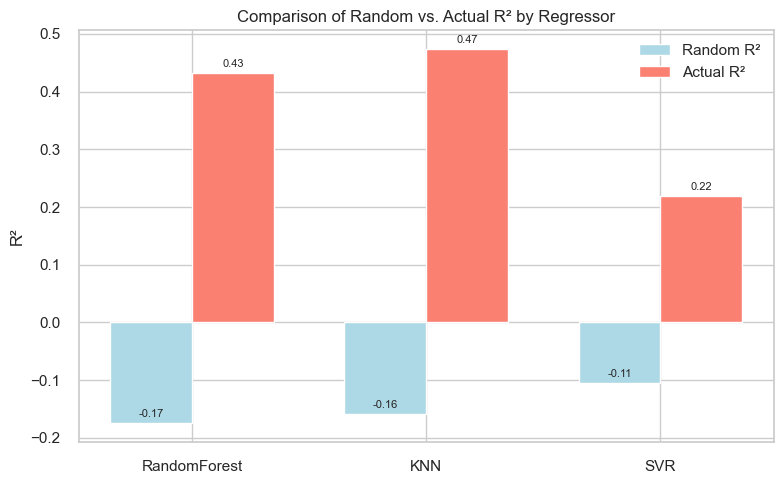

In [3]:
plot_random_vs_actual_bars_regression(final_table)
